Componentes óptimos (95% varianza): 13
Varianza explicada: 95.33%


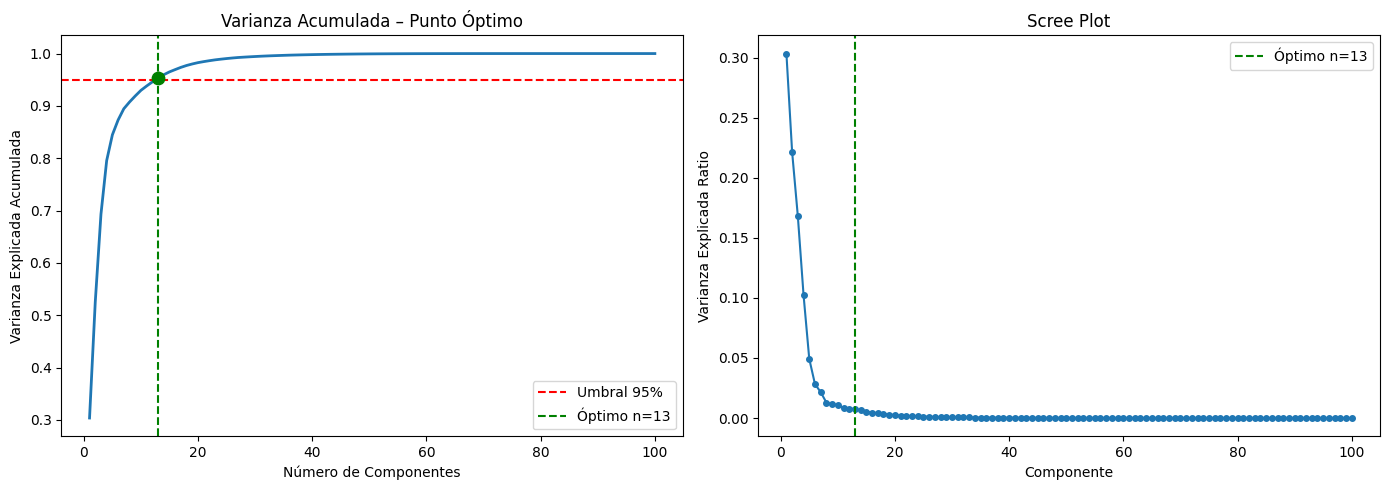


Forma reducida: (25005, 13)  (100 → 13 componentes)
Varianza total explicada: 95.33%


In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('data/clothDataset_96_.csv')

num_vertices = 25
num_features = 4  # x, y, z, sdf

df = df.drop(columns=['frame'])

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', 
                             #f'vx{i}', f'vy{i}', f'vz{i}', 
                             f'sdf{i}'])
df = df[selected_columns]

# Escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# ── Step 1: Detectar el número óptimo de componentes (umbral 95%) ──
pca_full = PCA()
pca_full.fit(df_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumulative_variance >= 0.95)) + 1

print(f"Componentes óptimos (95% varianza): {optimal_n}")
print(f"Varianza explicada: {cumulative_variance[optimal_n - 1]:.2%}")

# ── Step 2: Gráfico de varianza acumulada con el punto óptimo marcado ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva acumulada
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumulative_variance[optimal_n - 1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title('Varianza Acumulada – Punto Óptimo')
axes[0].legend()

# Scree plot (varianza individual)
axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             pca_full.explained_variance_ratio_, 'o-', markersize=4)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Explicada Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Step 3: Aplicar PCA con el número óptimo ──
pca = PCA(n_components=optimal_n)
df_pca = pca.fit_transform(df_scaled)

print(f"\nForma reducida: {df_pca.shape}  ({df_scaled.shape[1]} → {optimal_n} componentes)")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")

In [15]:
# Ver qué features dominan cada componente
# SOLO SI PCA CN 4 FEATURES
"""
import pandas as pd

feature_names = []
for i in range(6):
    feature_names.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

components_df = pd.DataFrame(
    df_pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(optimal_n)]
)

print(components_df.round(3).to_string())
"""
a = 0

Columnas totales usadas para PCA: 100
Componentes PCA óptimos (95% varianza): 13  [varianza explicada: 95.44%]


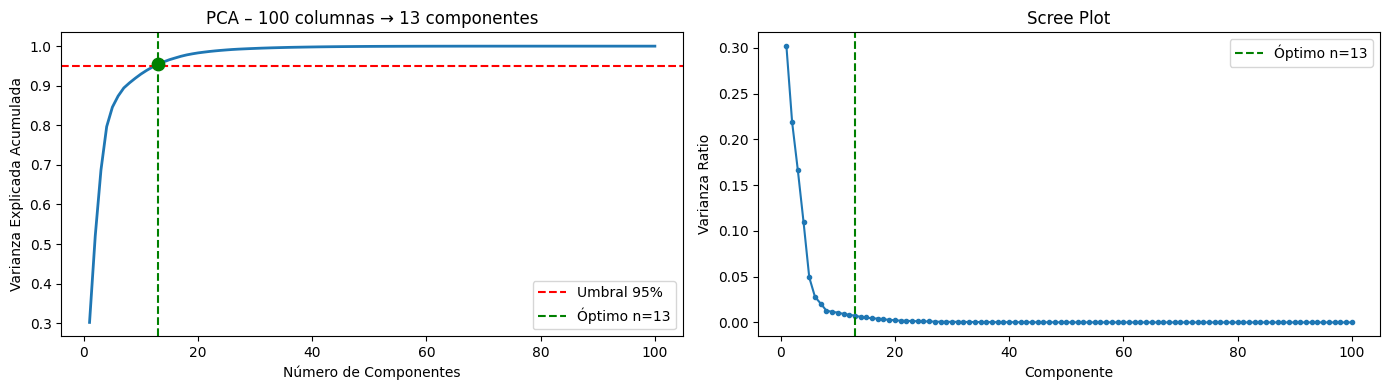

Forma train: (20004, 100) → (20004, 13)
Forma test:  (5001, 100)  → (5001, 13)
Tensor entrada PCA train: torch.Size([20004, 1, 13])
Tensor entrada PCA test:  torch.Size([5001, 1, 13])
Tensor XYZ train:         torch.Size([20004, 25, 3])
Tensor XYZ test:          torch.Size([5001, 25, 3])


In [16]:
#ADAPTAR DATAFRAME PARA EL RNN
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_frames   = df.shape[0]

data_flat_raw = df.values  # (N, num_vertices*13)
total_columns = data_flat_raw.shape[1]
print(f"Columnas totales usadas para PCA: {total_columns}")

# ── Split cronológico ANTES de ajustar scaler/PCA para evitar data leakage ──
train_size = int(0.8 * num_frames)
data_train_raw = data_flat_raw[:train_size]
data_test_raw  = data_flat_raw[train_size:]

# ── StandardScaler ajustado SOLO sobre train ──
input_scaler = StandardScaler()
data_train_scaled = input_scaler.fit_transform(data_train_raw)
data_test_scaled  = input_scaler.transform(data_test_raw)

# ── PCA ajustado SOLO sobre train ──
pca_search = PCA()
pca_search.fit(data_train_scaled)
cumvar = pca_search.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Componentes PCA óptimos (95% varianza): {optimal_n}  "
      f"[varianza explicada: {cumvar[optimal_n-1]:.2%}]")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1, len(cumvar)+1), cumvar, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumvar[optimal_n-1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title(f'PCA – {total_columns} columnas → {optimal_n} componentes')
axes[0].legend()
axes[1].plot(range(1, len(pca_search.explained_variance_ratio_)+1),
             pca_search.explained_variance_ratio_, 'o-', markersize=3)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()
plt.tight_layout()
plt.show()

# ── PCA definitivo ajustado sobre train, aplicado a ambos splits ──
input_pca = PCA(n_components=optimal_n)
data_train_pca = input_pca.fit_transform(data_train_scaled)  # (N_train, optimal_n)
data_test_pca  = input_pca.transform(data_test_scaled)       # (N_test,  optimal_n)

print(f"Forma train: {data_train_raw.shape} → {data_train_pca.shape}")
print(f"Forma test:  {data_test_raw.shape}  → {data_test_pca.shape}")

# ── Extraer XYZ real para calcular deltas target ──
xyz_cols = []
for i in range(num_vertices):
    xyz_cols.extend([f'x{i}', f'y{i}', f'z{i}'])
data_xyz = df[xyz_cols].values  # (N, num_vertices*3)
data_xyz_3d = data_xyz.reshape(num_frames, num_vertices, 3)
xyz_tensor = torch.tensor(data_xyz_3d, dtype=torch.float32)

# Splits XYZ alineados con splits PCA
xyz_train = xyz_tensor[:train_size]
xyz_test  = xyz_tensor[train_size:]

# ── Reshape PCA a 3D: (N, 1, optimal_n) ──
data_train_tensor = torch.tensor(data_train_pca.reshape(-1, 1, optimal_n), dtype=torch.float32)
data_test_tensor  = torch.tensor(data_test_pca.reshape(-1, 1, optimal_n),  dtype=torch.float32)

print(f"Tensor entrada PCA train: {data_train_tensor.shape}")
print(f"Tensor entrada PCA test:  {data_test_tensor.shape}")
print(f"Tensor XYZ train:         {xyz_train.shape}")
print(f"Tensor XYZ test:          {xyz_test.shape}")


In [17]:
class ClothSequenceDataset(Dataset):
    def __init__(self, pca_frames, xyz_frames, seq_len=5):
        """
        pca_frames : Tensor [Total_Frames, 1, n_components]  – entrada comprimida
        xyz_frames : Tensor [Total_Frames, Vertices, 3]      – posiciones XYZ reales
        seq_len    : frames históricos que usa la RNN
        """
        self.pca_frames = pca_frames if isinstance(pca_frames, torch.Tensor) \
                           else torch.tensor(pca_frames, dtype=torch.float32)
        self.xyz_frames = xyz_frames if isinstance(xyz_frames, torch.Tensor) \
                           else torch.tensor(xyz_frames, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        # -seq_len para la historia inicial, -1 para tener target del último frame
        #return len(self.pca_frames) - self.seq_len - 1
        # CORREGIDO: Restamos 2 * seq_len para asegurar que tanto la historia
        # como el rollout futuro quepan por completo dentro de los límites del tensor.
        return len(self.pca_frames) - 2 * self.seq_len + 1

    def __getitem__(self, idx):
        # Historia PCA: [Seq_Len, 1, n_components]
        seq_pca = self.pca_frames[idx : idx + self.seq_len]

        # XYZ real de los frames futuros del rollout: devolvemos W=seq_len pasos
        # future_xyz: [W, Vertices, 3] — usado por run_rollout
        future_xyz = self.xyz_frames[idx + self.seq_len - 1 : idx + self.seq_len - 1 + self.seq_len + 1]

        return seq_pca, future_xyz


seq_length = 8
batch_size = 32
ROLLOUT_STEPS = 12  # pasos de rollout durante entrenamiento

train_dataset = ClothSequenceDataset(data_train_tensor, xyz_train, seq_len=seq_length)
test_dataset  = ClothSequenceDataset(data_test_tensor,  xyz_test,  seq_len=seq_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Verificar shapes
for batch_seq, batch_future_xyz in train_loader:
    print(f"Entrada RNN (PCA):    {batch_seq.shape}")        # [B, seq_len, 1, optimal_n]
    print(f"XYZ futuros:          {batch_future_xyz.shape}") # [B, seq_len+1, V, 3]
    break


Entrada RNN (PCA):    torch.Size([32, 8, 1, 13])
XYZ futuros:          torch.Size([32, 9, 25, 3])


In [18]:
import torch
import torch.nn as nn

class FlatRNNClothUnity(nn.Module):
    def __init__(self, n_pca_components, num_vertices, hidden_size, num_outputs=3):
        """
        n_pca_components : número de componentes PCA (entrada comprimida por frame)
        num_vertices     : vértices del tejido (para reconstruir la salida)
        hidden_size      : tamaño del estado oculto de la RNN
        num_outputs      : coordenadas a predecir por vértice (3 → delta XYZ)
        """
        super(FlatRNNClothUnity, self).__init__()

        self.num_vertices = num_vertices
        self.num_outputs  = num_outputs

        # La entrada por frame es el vector PCA aplanado (1 × n_pca_components)
        self.input_size = n_pca_components

        self.rnn_cell = nn.RNNCell(
            input_size=self.input_size,
            hidden_size=hidden_size,
            nonlinearity='relu'
        )

        # Salida: delta XYZ para cada vértice (en espacio original)
        self.fc = nn.Linear(hidden_size, num_vertices * num_outputs)

    def forward(self, x):
        # x: [Batch, Seq_Len, 1, n_pca_components]
        batch_size = x.size(0)
        seq_len    = x.size(1)

        # Aplanar dimensión de vértices (solo hay 1): [Batch, Seq_Len, n_pca_components]
        x_flat = x.view(batch_size, seq_len, -1)

        h_t = torch.zeros(batch_size, self.rnn_cell.hidden_size, device=x.device)
        for t in range(seq_len):
            h_t = self.rnn_cell(x_flat[:, t, :], h_t)

        # Proyección a delta XYZ
        pred_flat  = self.fc(h_t)                                   # [Batch, Vertices*3]
        pred_delta = pred_flat.view(batch_size, self.num_vertices, self.num_outputs)
        return pred_delta  # [Batch, Vertices, 3]  – delta XYZ real


In [19]:
import torch
import json
import numpy as np

# ==============================================================================
# 1. COMPUTE TARGET STATS (solo sobre train para evitar data leakage)
# ==============================================================================
all_target_deltas = []
for batch_seq, batch_future_xyz in train_loader:
    # delta entre frame t y t+1 para todos los pasos del rollout
    for k in range(batch_future_xyz.shape[1] - 1):
        delta = batch_future_xyz[:, k+1, :, :] - batch_future_xyz[:, k, :, :]  # [B, V, 3]
        all_target_deltas.append(delta.reshape(-1, 3))

full_target_tensor = torch.cat(all_target_deltas, dim=0)
target_mean = full_target_tensor.mean(dim=0)  # [3]
target_std  = full_target_tensor.std(dim=0)   # [3]
print("target_mean:", target_mean)
print("target_std: ", target_std)

# ==============================================================================
# 2. SAVE NORM PARAMS TO JSON
# ==============================================================================
norm_data = {
    "input_scaler_mean": input_scaler.mean_.tolist(),
    "input_scaler_std":  input_scaler.scale_.tolist(),
    "pca_components":    input_pca.components_.flatten().tolist(),
    "pca_mean":          input_pca.mean_.tolist(),
    "target_mean":       target_mean.tolist(),
    "target_std":        target_std.tolist(),
    "optimal_n":         optimal_n,
    "num_vertices":      num_vertices,
}
with open("bigPCA_norm_params.json", "w") as f:
    json.dump(norm_data, f)
print("Parámetros guardados en bigPCA_norm_params.json")

# ==============================================================================
# 3. SETUP MODEL
# ==============================================================================
model     = FlatRNNClothUnity(n_pca_components=optimal_n, num_vertices=num_vertices,
                               hidden_size=128, num_outputs=3)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

print(f"Modelo creado | input_size={optimal_n} | output={num_vertices*3} ({num_vertices} vértices × 3)")
print(f"PCA components shape: {input_pca.components_.shape}")


target_mean: tensor([ 9.7660e-06,  2.0750e-06, -1.3528e-08])
target_std:  tensor([0.0136, 0.0038, 0.0018])
Parámetros guardados en bigPCA_norm_params.json
Modelo creado | input_size=13 | output=75 (25 vértices × 3)
PCA components shape: (13, 100)


In [ ]:
# ==============================================================================
# TRAINING & TESTING LOOP CON ROLLOUT
# ==============================================================================

EPOCHS      = 50
NOISE_SIGMA = 0.03
VEL_WEIGHT  = 1.0
fixedDeltaTime = 0.02  # debe coincidir con Time.fixedDeltaTime de Unity

"""
#BORRAR????
# Índices de las columnas de velocidad en el vector raw (vx, vy, vz por vértice)
# Orden CSV: x,y,z,vx,vy,vz,sdf,nx,ny,nz,md,u,v  → 13 features/vértice
# La velocidad está en cols [v*13+3, v*13+4, v*13+5]
vel_col_indices = []
for v in range(num_vertices):
    vel_col_indices.extend([v*num_features+3, v*num_features+4, v*num_features+5])
vel_col_indices = torch.tensor(vel_col_indices, dtype=torch.long)


def xyz_to_pca_frame(xyz_batch):

    Reconstruye el frame PCA a partir de posiciones XYZ predichas.
    xyz_batch: [B, V, 3] — posiciones predichas
    pred_vel:  [B, V, 3] — velocidades calculadas desde posiciones predichas
    Devuelve tensor PCA [B, 1, optimal_n]

    NOTA: solo actualizamos pos y vel en el vector raw; el resto de features
    (sdf, normal, maxDist, uv) se mantienen del frame real más cercano disponible,
    igual que en Unity donde el SDF se recalcula pero las UVs/normals son del mesh.

    B = xyz_batch.shape[0]
    return None  # placeholder — ver uso dentro de run_rollout

"""

def run_rollout(batch_seq_pca, batch_future_xyz, add_noise=False):
    """
    batch_seq_pca:    [B, seq_len, 1, optimal_n]  — historia inicial en espacio PCA
    batch_future_xyz: [B, W+1, V, 3]              — posiciones XYZ reales futuras
                      (índice 0 = frame actual, índices 1..W = targets)
    Retorna el loss acumulado (posición + velocidad) sobre W pasos.
    """
    B = batch_seq_pca.shape[0]
    W = batch_future_xyz.shape[1] - 1  # pasos de rollout

    window_pca = batch_seq_pca.clone()  # [B, seq_len, 1, optimal_n]

    if add_noise:
        window_pca = window_pca + torch.randn_like(window_pca) * NOISE_SIGMA

    total_loss = torch.tensor(0.0, device=batch_seq_pca.device)

    # Posición del frame anterior para calcular velocidad predicha
    prev_pred_xyz = batch_future_xyz[:, 0, :, :]  # [B, V, 3] — frame actual real

    # Buffer raw completo del último frame real (para reutilizar features no-pos/vel)
    # Lo usamos para reconstruir el vector raw con pos/vel predichos
    # Tomamos el último frame de la historia del dataset (antes del rollout)
    # Índice en el dataset original: necesitamos el raw del frame t actual
    # Como no lo tenemos directamente, lo reconstruimos desde scaler+pca inverse.
    # En la práctica, para SDF y features extra usamos los del ground truth (igual que antes).

    for k in range(W):
        # ── Forward ────────────────────────────────────────────────
        pred_delta_norm = model(window_pca)           # [B, V, 3] delta normalizado

        last_xyz    = batch_future_xyz[:, k, :, :]    # posición actual real [B, V, 3]
        real_xyz_next = batch_future_xyz[:, k+1, :, :]  # target real [B, V, 3]

        # ── Desnormalizar delta predicho ──
        pred_delta_real = pred_delta_norm * target_std + target_mean  # [B, V, 3]
        pred_xyz = last_xyz + pred_delta_real                         # [B, V, 3]

        # ── Loss posición ──────────────────────────────────────────
        real_delta      = real_xyz_next - last_xyz
        real_delta_norm = (real_delta - target_mean) / target_std
        loss_pos = criterion(pred_delta_norm, real_delta_norm)

        # ── Loss velocidad desde posiciones predichas ───────────────
        # Igual que Unity: vel = (pos_t - pos_t-1) / fixedDeltaTime
        pred_vel = (pred_xyz - prev_pred_xyz)# / fixedDeltaTime   # [B, V, 3]
        real_vel = (real_xyz_next - batch_future_xyz[:, k, :, :])# / fixedDeltaTime
        loss_vel = criterion(
            pred_vel / target_std.clamp(min=1e-8),
            real_vel / target_std.clamp(min=1e-8)
        )

        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # ── Construir nuevo frame PCA desde pred_xyz ────────────────
        # 1. Tomar el vector raw del frame k+1 como base (para sdf, normals, uv, etc.)
        #    Reconstruimos el raw escalado del frame actual desde el ground truth
        #    y reemplazamos solo las columnas de pos y vel con las predichas.
        #
        #    LIMITACIÓN: SDF y normales siguen siendo del ground truth porque
        #    requieren geometría de Unity. Esto es el mismo compromiso que antes.

        # Obtener raw del frame k+1 del ground truth (shape: [B, total_columns])
        # Para ello necesitamos acceder al dataset raw — pasamos raw_future como arg extra
        # Por ahora lo aproximamos via inverse_transform del PCA (aproximación)
        current_pca_np = window_pca[:, -1, 0, :].detach().cpu().numpy()  # [B, optimal_n]
        raw_approx = input_pca.inverse_transform(current_pca_np)          # [B, total_columns]
        raw_approx = torch.tensor(raw_approx, dtype=torch.float32, device=batch_seq_pca.device)

        # Reemplazar columnas de posición con las predichas
        raw_pred = raw_approx.clone()
        for v in range(num_vertices):
            base = v * num_features
            # Posición predicha (desnormalizada con input_scaler)
            pos_scaled = (pred_xyz[:, v, :] - torch.tensor(input_scaler.mean_[[base, base+1, base+2]], dtype=torch.float32)) \
                         / torch.tensor(input_scaler.scale_[[base, base+1, base+2]], dtype=torch.float32)
            #vel_scaled = (pred_vel[:, v, :] - torch.tensor(input_scaler.mean_[[base+3, base+4, base+5]], dtype=torch.float32)) \
            #             / torch.tensor(input_scaler.scale_[[base+3, base+4, base+5]], dtype=torch.float32)
            raw_pred[:, base:base+3]   = pos_scaled
            #raw_pred[:, base+3:base+6] = vel_scaled

        # Centrar con pca_mean y proyectar
        pca_mean_t   = torch.tensor(input_pca.mean_, dtype=torch.float32, device=batch_seq_pca.device)
        pca_comp_t   = torch.tensor(input_pca.components_, dtype=torch.float32, device=batch_seq_pca.device)  # [optimal_n, total_cols]
        centered     = raw_pred - pca_mean_t                                    # [B, total_cols]
        new_pca_vec  = centered @ pca_comp_t.T                                  # [B, optimal_n]
        new_frame    = new_pca_vec.unsqueeze(1).unsqueeze(1)                    # [B, 1, 1, optimal_n]

        # Deslizar ventana
        if model.training:
            window_pca = torch.cat([window_pca[:, 1:, :, :], new_frame], dim=1)
        else:
            window_pca = torch.cat([window_pca[:, 1:, :, :], new_frame.detach()], dim=1)

        prev_pred_xyz = pred_xyz

    return total_loss / W


# ==============================================================================
# BUCLE DE ENTRENAMIENTO
# ==============================================================================
history = {'train': [], 'test': [], 'vertex_error': []}

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch_seq, batch_future_xyz in train_loader:
        batch_seq         = batch_seq.float()
        batch_future_xyz  = batch_future_xyz.float()

        loss = run_rollout(batch_seq, batch_future_xyz, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────
    model.eval()
    test_loss  = 0.0
    total_err  = 0.0
    total_verts = 0

    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future_xyz in test_loader:
            batch_seq        = batch_seq.float()
            batch_future_xyz = batch_future_xyz.float()

            loss = run_rollout(batch_seq, batch_future_xyz, add_noise=False)
            test_loss += loss.item()

            # Métrica 1-paso para monitorización rápida
            pred_dn   = model(batch_seq)
            last_xyz  = batch_future_xyz[:, 0, :, :]
            pred_pos  = last_xyz + pred_dn * target_std + target_mean
            target_pos = batch_future_xyz[:, 1, :, :]

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances    = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss / len(test_loader)
    avg_vert_err = total_err / total_verts


    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 10 == 0 or epoch == 1:        
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f}")

print("\nEntrenamiento completado.")


Epoch 001 | Train: 0.508907 | Test: 0.474336 | VertErr: 0.008626
Epoch 010 | Train: 0.398954 | Test: 0.340799 | VertErr: 0.004871
Epoch 020 | Train: 0.384080 | Test: 0.330182 | VertErr: 0.004862
Epoch 030 | Train: 0.376251 | Test: 0.323421 | VertErr: 0.004803
Epoch 040 | Train: 0.370850 | Test: 0.320752 | VertErr: 0.004817
Epoch 050 | Train: 0.366209 | Test: 0.318767 | VertErr: 0.004831
Epoch 060 | Train: 0.362459 | Test: 0.319940 | VertErr: 0.004925


KeyboardInterrupt: 

In [ ]:
"""
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Combinar los batches recogidos en arrays únicos
preds_np   = np.concatenate(all_pred_deltas,  axis=0)  # (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # (Total_Frames, Vertices, 3)

# 2. Reshape a 2D: (Total_Frames, Vertices * 3)
preds_2d   = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# ── Detectar número óptimo de componentes sobre los targets ──
pca_full = PCA()
pca_full.fit(targets_2d)
cumvar = pca_full.explained_variance_ratio_.cumsum()
optimal_n_eval = int(np.argmax(cumvar >= 0.95)) + 1
optimal_n_eval = min(optimal_n_eval, targets_2d.shape[1])  # no puede superar las features

print(f"Componentes óptimos para visualización post-entrenamiento: {optimal_n_eval}")
print(f"Varianza explicada (targets): {cumvar[optimal_n_eval - 1]:.2%}")

# ── Gráfico de varianza para la evaluación ──
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
plt.axvline(x=optimal_n_eval, color='g', linestyle='--', label=f'Óptimo n={optimal_n_eval}')
plt.scatter([optimal_n_eval], [cumvar[optimal_n_eval - 1]], color='g', zorder=5, s=80)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA Evaluación – Varianza de los Targets')
plt.legend()
plt.tight_layout()
plt.show()

# ── Ajustar PCA sobre targets (espacio compartido) y transformar ambos ──
pca_eval = PCA(n_components=optimal_n_eval)
pca_eval.fit(targets_2d)
pca_targets = pca_eval.transform(targets_2d)
pca_preds   = pca_eval.transform(preds_2d)

# ── Visualización: siempre 2D con PC1 vs PC2 ──
plt.figure(figsize=(10, 8))
plt.scatter(pca_targets[:, 0], pca_targets[:, 1],
            alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)
plt.scatter(pca_preds[:, 0],   pca_preds[:, 1],
            alpha=0.5, label='Predicciones del Modelo', color='red',  s=10)
plt.title(f'PCA Cloth Dynamics – Ground Truth vs Predicciones\n'
          f'(usando {optimal_n_eval} componentes óptimos, mostrando PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca_eval.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'PC2 ({pca_eval.explained_variance_ratio_[1]:.2%} var)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Si hay 3+ componentes, añadir vista 3D ──
if optimal_n_eval >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pca_targets[:, 0], pca_targets[:, 1], pca_targets[:, 2],
               alpha=0.4, label='Ground Truth', color='blue', s=8)
    ax.scatter(pca_preds[:, 0],   pca_preds[:, 1],   pca_preds[:, 2],
               alpha=0.4, label='Predicciones',  color='red',  s=8)
    ax.set_title(f'PCA 3D – PC1 vs PC2 vs PC3  (n_optimal={optimal_n_eval})')
    ax.set_xlabel(f'PC1 ({pca_eval.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca_eval.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca_eval.explained_variance_ratio_[2]:.2%})')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Vista 3D generada (PC1, PC2, PC3)")
else:
    print("Solo 2 componentes óptimos – se muestra únicamente la vista 2D.")
    """

'\nfrom sklearn.decomposition import PCA\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# 1. Combinar los batches recogidos en arrays únicos\npreds_np   = np.concatenate(all_pred_deltas,  axis=0)  # (Total_Frames, Vertices, 3)\ntargets_np = np.concatenate(all_target_deltas, axis=0) # (Total_Frames, Vertices, 3)\n\n# 2. Reshape a 2D: (Total_Frames, Vertices * 3)\npreds_2d   = preds_np.reshape(preds_np.shape[0], -1)\ntargets_2d = targets_np.reshape(targets_np.shape[0], -1)\n\n# ── Detectar número óptimo de componentes sobre los targets ──\npca_full = PCA()\npca_full.fit(targets_2d)\ncumvar = pca_full.explained_variance_ratio_.cumsum()\noptimal_n_eval = int(np.argmax(cumvar >= 0.95)) + 1\noptimal_n_eval = min(optimal_n_eval, targets_2d.shape[1])  # no puede superar las features\n\nprint(f"Componentes óptimos para visualización post-entrenamiento: {optimal_n_eval}")\nprint(f"Varianza explicada (targets): {cumvar[optimal_n_eval - 1]:.2%}")\n\n# ── Gráfico de varianza para la evalua

: 

: 

: 

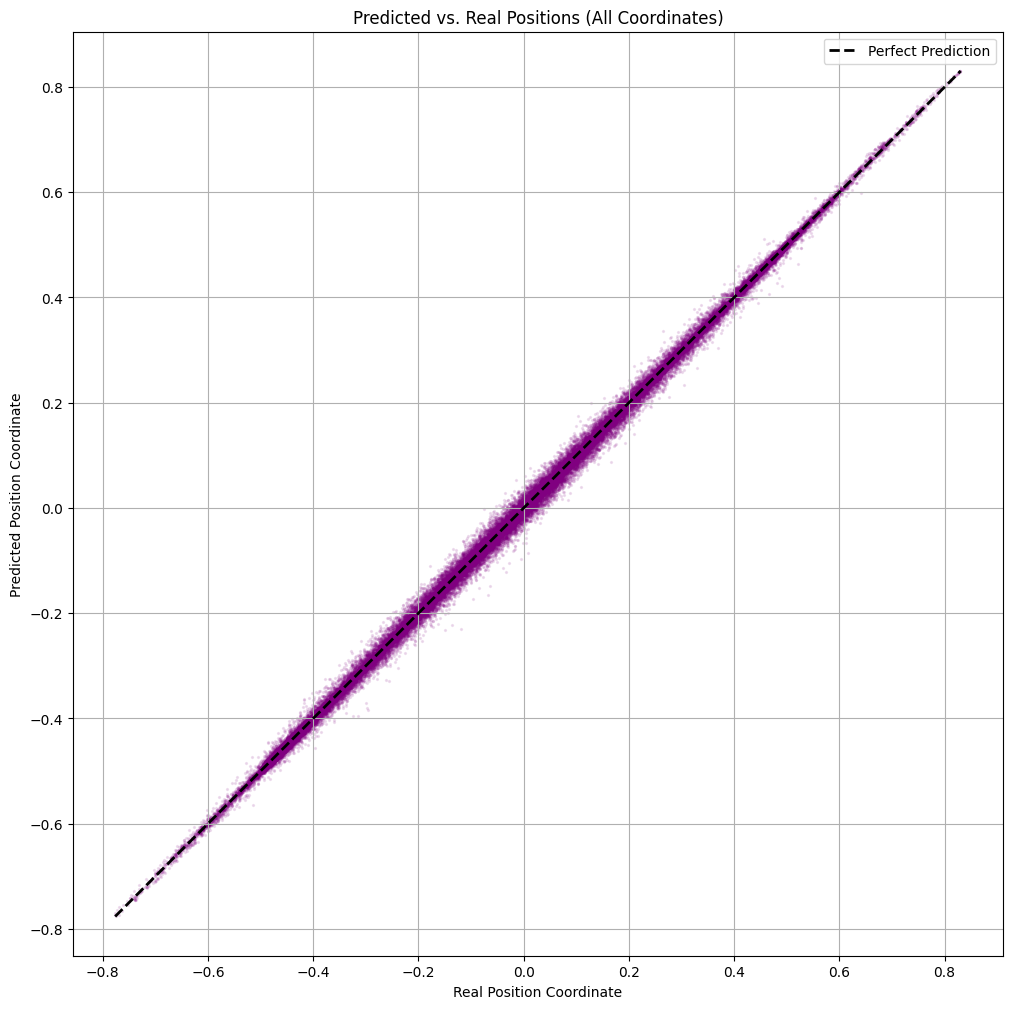

In [21]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

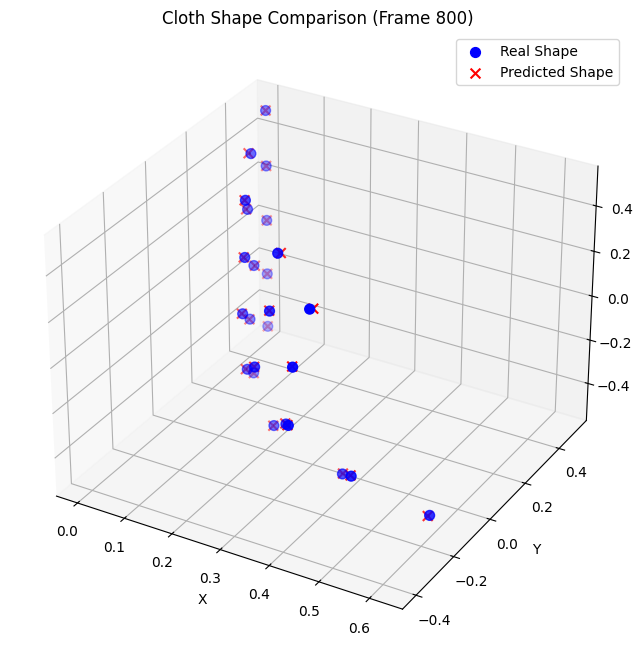

In [22]:
# Choose a random frame from your test set to visualize
frame_idx = 800 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [23]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. NUEVO: Creamos el dummy input con 4 dimensiones: 
# [Batch=1, Seq_Len=5, Vertice virtual=1, FeaturesPCA=optimal_n]
dummy_input = torch.randn(1, seq_length, 1, optimal_n)

# 3. Export to ONNX (el resto se mantiene igual)
onnx_program = torch.onnx.export(
    model,                      
    dummy_input,                # Tu [1, 5, 1, optimal_n]
    "big_PCA_rnn.onnx", 
    export_params=True,         
    opset_version=15,           # <--- Subir a 15
    input_names=['input'],      
    output_names=['output'],    
)

print("Exported to ONNX with strict 4D sequential shapes!")

Exported to ONNX with strict 4D sequential shapes!
